For immersion: https://www.youtube.com/watch?v=sdBrscwwy_c

# 🌟 Operation NeuroNexus

Trondheim lies under the iron grip of SkyNet, an AI system that has seized control of the city's entire digital infrastructure. You and your team of elite hackers have been tasked with a crucial mission: infiltrate SkyNet's systems, decode its defenses, and liberate the city from its digital oppressor.

## 🎯 Mission Overview

Operation NeuroNexus consists of four independent, yet interconnected missions. Each mission targets a different aspect of SkyNet's infrastructure and requires you to apply various Supervised Learning techniques covered in this course.

## 📊 Mission Structure

1. Each mission has a specific task related to combating SkyNet.
2. Following the task description, you'll find a set of formal requirements that your solution must meet.
3. The primary measure of your success is the accuracy of your machine learning model.
4. After completing each task, you must answer a series of questions to demonstrate your understanding of the techniques used.

## 🧪 A Note on Test Data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each mission. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission Guidelines

- For each mission, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.


Good luck! The resistance is counting on you.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 🌞 Mission 1: Predicting SkyNet's Power Consumption

### 🎯 The Mission
Intelligence suggests that SkyNet has a critical weakness: **its power consumption**. We must understand its energy needs to plan a coordinated strike.

### 🧠 Your Task
Develop a predictive model to estimate SkyNet's power consumption based on its **Network Activity**.

**Goal**: Implement a **Linear Regression model using Gradient Descent, from scratch**.

Use `LinearRegression` class from `linear_regression.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

> Note: The `%autoreload` IPython magic command allows instant updates from `linear_regression.py`.

### 📊 Formal Requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement gradient descent

2. **Discussion**:

   a. Visualize the fitted curve. Derive the resulting Energy consumption formula.
   
   b. Analyze prediction error distribution. What is an unbiased estimator?

---

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Import your implementation
from linear_regression import LinearRegression # <--- This is your implementation

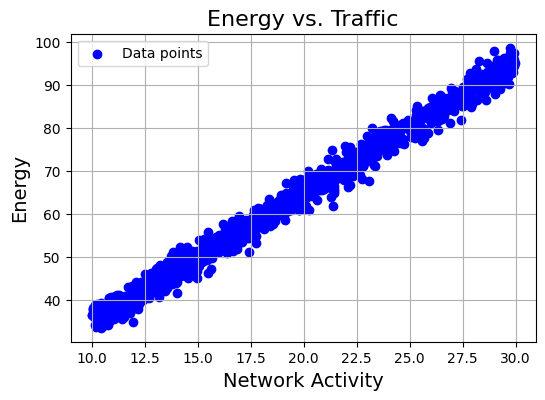

In [4]:
# Load data
data = pd.read_csv('mission1.csv')

plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

In [5]:
#Learning rate is slower than 0.1 since overflow happens to the X value, so it overshot the minimum of the slope
lr = LinearRegression(learning_rate=0.001, epochs=1000)

X = data[['Net_Activity']].values
y = data['Energy'].values


lr.fit(X, y) 

y_pred = lr.predict(X)

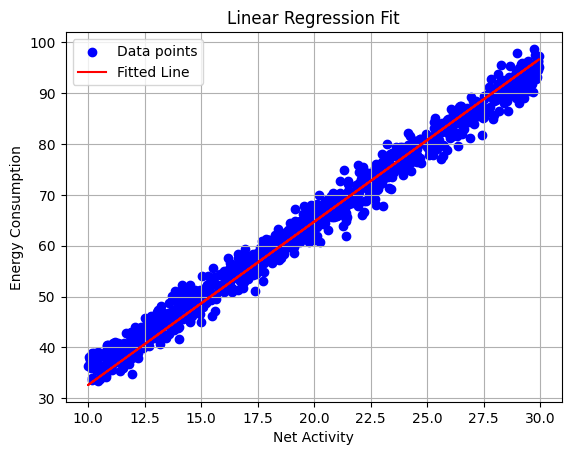

In [6]:
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)

# Plot regression line
plt.plot(X, y_pred, color="red", label="Fitted Line")

plt.xlabel("Net Activity")
plt.ylabel("Energy Consumption")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [7]:
print(f"Fitted formula: Energy ≈ {lr.weights[0]:.4f} * Net_Activity + {lr.bias:.4f}")

Fitted formula: Energy ≈ 3.2117 * Net_Activity + 0.4939


In [8]:
error = y_pred - y

In [9]:
print("Mean of residuals:", np.mean(error))
print("Std of residuals:", np.std(error, ddof=1))

Mean of residuals: -0.33207853315998115
Std of residuals: 2.307112240479732


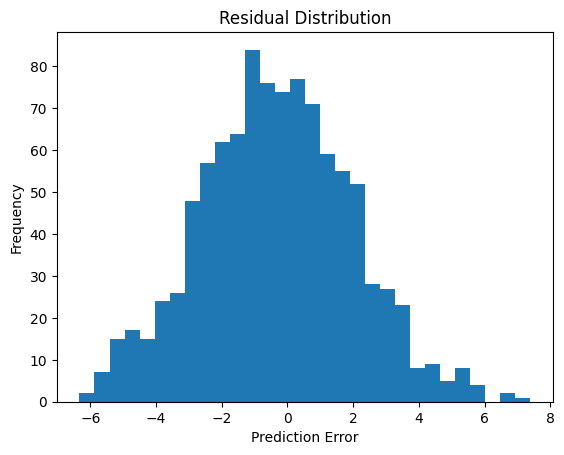

In [10]:
# Histogram
plt.hist(error, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

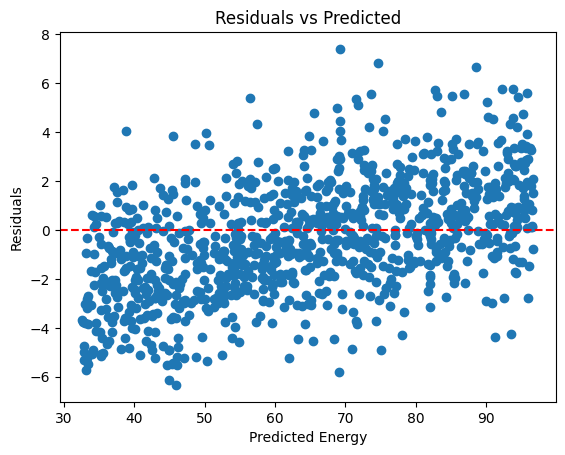

In [11]:
# Residuals vs Fitted
plt.scatter(y_pred, error)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Energy")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

## Unbiased estimator
An unbiased estimator is an estimator whose expected value is equal to the true value of the parameter. 
Meaning if we could repeat the sampling process very many times and compute the estimator each time, then on average, those estimates would equal the true parameter.

## 🧠 Mission 2: Decoding SkyNet's signals

### 🌐 The Discovery
We've intercepted two types of signals that may determine SkyNet's next moves.

### 🎯 Your Mission
1. Evolve your linear regression into logistic regression
2. Engineer features to unravel hidden connections
3. Predict SkyNet's binary decisions (0 or 1) from paired signals

### 📊 Formal Requirements
1. **Implementation**: 
   - Use standard Python libraries
   - Implement gradient descent

2. **Performance**: Achieve at least 0.88 accuracy on the test set

3. **Discussion**:

   a. Explain poor initial performance and your improvements

   b. What is the model's inductive bias. Why is it important?

   c. Try to solve the problem using `sklearn.tree.DecisionTreeClassifier`. Can it solve the problem? Why/Why not?
   
   d. Plot the ROC curve

---

In [12]:
data = pd.read_csv('mission2.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from logistic_regression import LogisticRegression 
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(train[['x0', 'x1']].values, train['y'].values, test_size=0.2)

In [15]:
print("X_train_features data: ", X_train[:10])
print("X_train_features data: ", X_test[:10])

X_train_features data:  [[-1.99847663  0.49418332]
 [-0.45614309  2.02339304]
 [ 0.65087866 -0.90832415]
 [ 0.53182912 -0.24816441]
 [ 0.15890359  0.89279041]
 [-0.92433487 -3.33925093]
 [ 0.18949196  0.69452306]
 [ 0.1626082  -2.38718287]
 [ 0.14476121  0.8067218 ]
 [-1.22379989 -2.05845582]]
X_train_features data:  [[-1.18741657  0.37182307]
 [ 0.37704383  0.58702325]
 [ 0.67298285 -0.44930297]
 [ 0.39131292  0.79310678]
 [-2.83435679  1.15542206]
 [-0.93154252  1.58076803]
 [-0.90232049  0.39512858]
 [-0.06317052  0.33261969]
 [-0.18713456 -0.03009225]
 [ 0.38415272 -1.38267917]]


In [16]:
# Original features
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Interaction term
X_train_fe = np.column_stack((X_train_fe, X_train[:,0] * X_train[:,1]))
X_test_fe = np.column_stack((X_test_fe, X_test[:,0] * X_test[:,1]))

# Quadratic terms
X_train_fe = np.column_stack((X_train_fe, X_train[:,0]**2, X_train[:,1]**2))
X_test_fe = np.column_stack((X_test_fe, X_test[:,0]**2, X_test[:,1]**2))

In [17]:
print("X_train_features data: ", X_train_fe[:10])
print("X_train_features data: ", X_test_fe[:10])

X_train_features data:  [[-1.99847663  0.49418332 -0.98761381  3.99390885  0.24421715]
 [-0.45614309  2.02339304 -0.92295675  0.20806652  4.0941194 ]
 [ 0.65087866 -0.90832415 -0.59120881  0.42364304  0.82505276]
 [ 0.53182912 -0.24816441 -0.13198106  0.28284221  0.06158558]
 [ 0.15890359  0.89279041  0.1418676   0.02525035  0.79707472]
 [-0.92433487 -3.33925093  3.08658609  0.85439496 11.15059679]
 [ 0.18949196  0.69452306  0.13160654  0.0359072   0.48236228]
 [ 0.1626082  -2.38718287 -0.38817551  0.02644143  5.69864207]
 [ 0.14476121  0.8067218   0.11678203  0.02095581  0.65080007]
 [-1.22379989 -2.05845582  2.519138    1.49768617  4.23724034]]
X_train_features data:  [[-1.18741657e+00  3.71823074e-01 -4.41508879e-01  1.40995811e+00
   1.38252399e-01]
 [ 3.77043829e-01  5.87023248e-01  2.21333493e-01  1.42162049e-01
   3.44596294e-01]
 [ 6.72982848e-01 -4.49302970e-01 -3.02373193e-01  4.52905914e-01
   2.01873159e-01]
 [ 3.91312916e-01  7.93106784e-01  3.10352928e-01  1.53125798e-01


In [18]:
min_max_scaler = MinMaxScaler()
X_train_fe = min_max_scaler.fit_transform(X_train_fe)
X_test_fe = min_max_scaler.transform(X_test_fe)

In [19]:
# Training
train_epochs = 100000
# Initialize and train the model
log_reg = LogisticRegression(learning_rate=0.5, epochs=train_epochs)
log_reg.fit(X_train_fe, y_train)
# Make predictions
predictions = log_reg.predict(X_test_fe)

In [20]:
y_pred = log_reg.predict(X_train_fe)

In [21]:
print("Accuracy: ", log_reg.accuracy(y_test, predictions))

Accuracy:  0.89


# 3A Explain poor initial performance and your improvements
First thing i did was changing the learning rate to 0.1 instead of 0.01 and epoch to 50000 instead of 1000. This made atleast the AI to learn a bit more from the document so i think it went from 0.56 to 0.61. Secondly I used interaction term. It multiplies X0 and x1 togheter to capture situations where the combination of xo and x1 togheter affect the output. After that I also used quadratic term to add the squared value of the data. It should help to improve the accuracy by allowing the model to learn curved bounderies and not only straight ones. After theses changes togheter I got around 0.84 accuracy. I tried more epochs but didnt work. I also tried useing randomness close to 0 as weight in the logistic regression but it helped but could do it consistently. I tried changing and refine logistic regression and upped the epoch and learning rate even more and now most of the time its above 0.88

# 3B What is the model's inductive bias. Why is it important?
The Model's inductive bias is that the model has "assumptions". It assumes that the probability of the output is a linear connection between the input features. When we add addition fetures like what i did by multiplying the values togheter and squaring the values as additional features, the model is forced to think less linear and get more accurate from it. The reason it is important is because without it the model wouldn't be able to predict anything, it would only memorize the training data and wouldn't then be able to predict any new examples.

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
clf = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
from sklearn.metrics import accuracy_score

y_pred_tree = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_tree)
print("Accuracy:", accuracy)

Accuracy: 0.93


Yes It solves the problem with ease! It automatically captures interaction between features and gets a high accuracy with me having to add the Interaction term and quadratic term to the data. I also doesnt assume that the data is linear.

In [25]:
# ROC Curve for the tree
roc_auc = roc_auc_score(y_test, y_pred_tree)
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.930


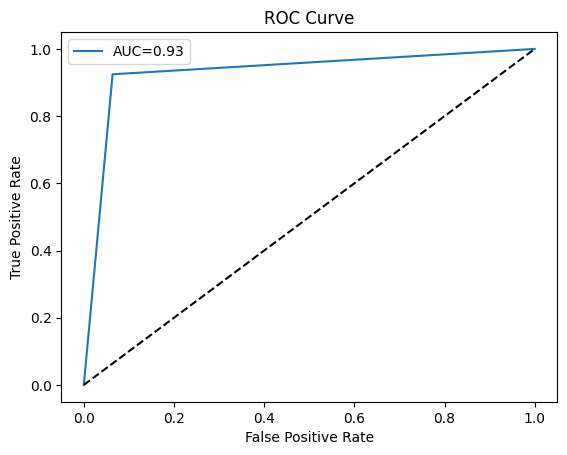

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_pred_tree)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
# ROC Curve for the Logistic regression
y_proba = log_reg.predict_proba(X_test_fe)
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.923


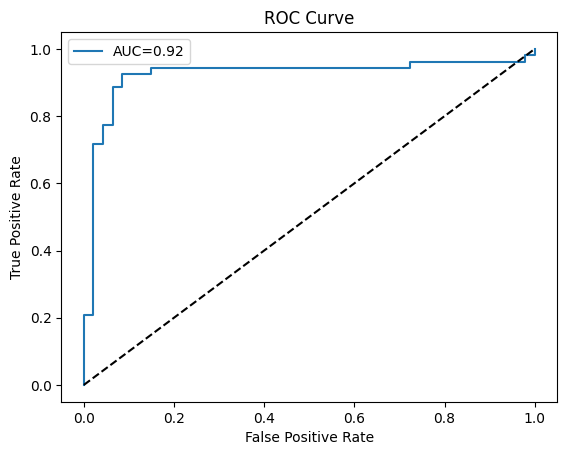

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 🌆 Mission 3: CyberGuard

### 🌐 The Discovery
SkyNet's drone communications use binary encryption. We need a system to intercept these messages.

### 🎯 Your Mission
Develop a decision tree classifier to process intercepted communications. Use `sklearn.tree.DecisionTreeClassifier`. 

Only one of the data streams needs to be decrypted, but you will need to identify the correct one.

To decrypt a data stream, transform the data into a binary representation based on whether the feature is even or odd.

### 📊 Formal Requirements
1. **Accuracy**: Achieve ROC AUC >= 0.72 on the test set
2. **Discussion**:

   a. Explain your threshold-breaking strategy. Did you change the default hyperparameters?

   b. Justify ROC AUC usage. Plot and interpret ROC.
   
   c. Try to solve the problem using sklearn’s Random Forest Classifier. Compare the results.

---

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
train = pd.read_csv('mission3_train.csv')
test = pd.read_csv('mission3_test.csv')

In [31]:
X_train = train.drop(columns=['target'])
y_train = train['target']
X_test  = test.drop(columns=['target'])
y_test  = test['target']

streams = X_train.columns.tolist()
print("Streams:", streams)

Streams: ['data_stream_0', 'data_stream_1', 'data_stream_2', 'data_stream_3', 'data_stream_4', 'data_stream_5', 'data_stream_6', 'data_stream_7', 'data_stream_8', 'data_stream_9', 'data_stream_10']


In [32]:
from decimal import Decimal
from sklearn import tree

In [33]:
def decrypt_last_digit(series):
    return np.array([int(str(abs(x)).replace('.', '')[-1]) % 2 for x in series])

def decrypt_multiply(series, factor):
    return np.array(((series * factor).astype(int) % 2))


def decrypt_multiply_dynamic(series):
    result = []
    for x in series:
        d = Decimal(str(abs(x)))
        decimals = max(-d.as_tuple().exponent, 0)
        factor = 10 ** decimals
        parity = int(abs(x) * factor) % 2
        result.append(parity)
    return np.array(result)



def float_val(series):
    return series

def squared(series):
    return series ** 2

def interaction(series, factor=1000):
    binary = decrypt_multiply(series, factor=factor)
    return series * binary

def log_transform(series):
    return np.log1p(series.abs()) * np.sign(series)


In [34]:
best_corr = 0
best_stream = None

for col in X_train.columns:
    binary_stream = decrypt_multiply_dynamic(X_train[col])
    corr = np.corrcoef(binary_stream, y_train)[0,1]
    print(f"{col} binary corr with target: {corr:.3f}")
    if abs(corr) > best_corr:
        best_corr = abs(corr)
        best_stream = col

print(f"Selected stream: {best_stream} (|corr|={best_corr:.3f})")
for col in X_train.columns:
    binary_stream = decrypt_multiply_dynamic(X_train[col])
    corr = np.corrcoef(((binary_stream + 1) % 2), y_train)[0,1]
    print(f"{col} binary corr with target: {corr:.3f}")
    if abs(corr) > best_corr:
        best_corr = abs(corr)
        best_stream = col

print(f"Selected stream: {best_stream} (|corr|={best_corr:.3f})")

data_stream_0 binary corr with target: -0.026
data_stream_1 binary corr with target: -0.016
data_stream_2 binary corr with target: -0.018
data_stream_3 binary corr with target: -0.187
data_stream_4 binary corr with target: -0.002
data_stream_5 binary corr with target: -0.016
data_stream_6 binary corr with target: 0.030
data_stream_7 binary corr with target: -0.016
data_stream_8 binary corr with target: -0.018
data_stream_9 binary corr with target: 0.013
data_stream_10 binary corr with target: 0.003
Selected stream: data_stream_3 (|corr|=0.187)
data_stream_0 binary corr with target: 0.026
data_stream_1 binary corr with target: 0.016
data_stream_2 binary corr with target: 0.018
data_stream_3 binary corr with target: 0.187
data_stream_4 binary corr with target: 0.002
data_stream_5 binary corr with target: 0.016
data_stream_6 binary corr with target: -0.030
data_stream_7 binary corr with target: 0.016
data_stream_8 binary corr with target: 0.018
data_stream_9 binary corr with target: -0.01

In [35]:
# depracated now - showcasing threshold values i tried to use
def create_features(series, smooth=False, window=3):
    if smooth:
        series = series.rolling(window=5, min_periods=1).mean()

    binary_dynamic = decrypt_multiply_dynamic(series)
    
    features = pd.DataFrame({
            #'float': series,
            #'abs': series.abs(),
            'binary_dynamic': binary_dynamic,
            #'float_x_bin': series * binary_dynamic,
 
    })

    decimals = series.apply(lambda x: max(-Decimal(str(x)).as_tuple().exponent, 0))
    features['decimals'] = decimals
    return features

In [36]:
best_roc = 0
best_params = {}

max_depth_list = [12] #list(range(1, 20))
min_samples_leaf_list = [43] #list(range(1, 51))
random_state_list = [7] #list(range(1, 51))
#list(range(20, 101))
X_train['data_stream_3'] = decrypt_multiply_dynamic(X_train['data_stream_3'])
X_test['data_stream_3']  = decrypt_multiply_dynamic(X_test['data_stream_3'])

for max_depth in max_depth_list:
    for min_samples_leaf in min_samples_leaf_list:
        for random_state_value in random_state_list:
            clf = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=random_state_value,
                criterion='log_loss',
                splitter = 'random',
                class_weight = 'balanced'
            )
            clf.fit(X_train, y_train)
            y_proba = clf.predict_proba(X_test)[:, 1]
            roc = roc_auc_score(y_test, y_proba)
            #tree.plot_tree(clf, fontsize=4); plt.savefig("tree.pdf")
    
            if roc > best_roc:
                best_roc = roc
                best_params = {
                    'max_depth': max_depth,
                    'min_samples_leaf': min_samples_leaf,
                    'random_state': random_state_value
                }

print("Best params:", best_params)
print("Best ROC-AUC:", best_roc)

Best params: {'max_depth': 12, 'min_samples_leaf': 43, 'random_state': 7}
Best ROC-AUC: 0.738444696984289


In [37]:
static_res = decrypt_multiply(X_train['data_stream_3'], factor=1000)
dynamic_res = decrypt_multiply_dynamic(X_train['data_stream_3'])

print("Static factor result:", static_res)
print("Dynamic factor result:", dynamic_res)
print("Difference:", static_res - dynamic_res)

Static factor result: [0 0 0 ... 0 0 0]
Dynamic factor result: [1 0 0 ... 1 1 1]
Difference: [-1  0  0 ... -1 -1 -1]


In [38]:
from sklearn.model_selection import GridSearchCV

In [39]:
param_grid = {
    'max_depth': [4, 6, 8, 10, 48],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 10, 50, 100, 200, 300, 400, 500, 600],
    'criterion': ['gini', 'entropy', 'log_loss']
}


In [40]:
clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best ROC-AUC:", grid_search.best_score_)

Best params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 50}
Best ROC-AUC: 0.684475687271158


 # 2 a. Explain your threshold-breaking strategy. Did you change the default hyperparameters?
I tried multiple things. Firstly I found out it was the Data stream 3 so I tried saving multiple values like the float, binary, interaction, square, cubed, negative, positive, absolute value, like everything, in different combinations and so on. In the end I found out the task ask for decrypting the stream 3 and still include all other streams as well for the ROC. I used brute force method for both depth, min leaves, and random state and having the splitter on random, so once I went through 20 thousand random states to get 0.68 ROC score earlier and now like 50 to get the score above 0.72. I also found the import of GridSearchCV that could do the same but it didn’t give the same score as if I used other parameters, which was weird. So my strategy in both was firstly trying to find the best parameters just by testing some but went to brute force since I used around 15 hours on this ROC score alone...

# 2 b. Justify ROC AUC usage. Plot and interpret ROC.
ROC AUC shows us the score of when I can hit true positives compared to false positives. The ROC curve itself plots the true positive rate against the false positive rate at different thresholds, so we can see how good the model is at separating the classes. Since we are decrypting messages, we need it to be accurate towards the true positives and not the false ones, which makes ROC AUC the right metric here.

In [41]:
#Takes the values from the function further up
clf = DecisionTreeClassifier(
            max_depth=12,
            min_samples_leaf=43,
            random_state=7,
            criterion='log_loss',
            splitter = 'random',
            class_weight = 'balanced'
        )
clf.fit(X_train, y_train)
y_proba = clf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc)

ROC-AUC: 0.738444696984289


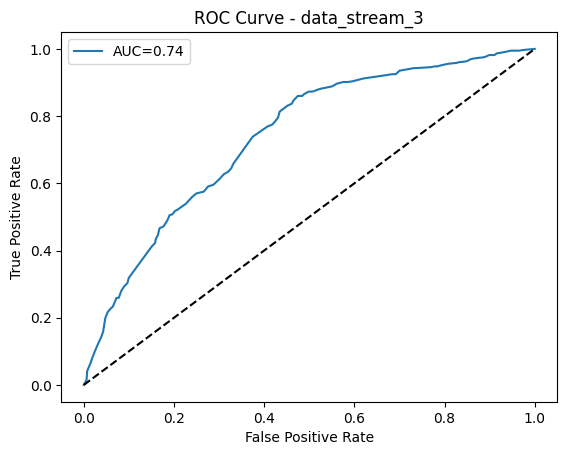

In [42]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_stream}")
plt.legend()
plt.show()

As you can see, the line is better than if the model were guessing randomly. The model is not perfectly stable, as can be seen by the line visibly being wiggly. Ideally, we would want it to be much closer to the top left corner, but we managed to achieve approximately 74% accuracy for the true positives.

# 2  c. Try to solve the problem using sklearn’s Random Forest Classifier. Compare the results.

In [43]:
from sklearn.ensemble import RandomForestClassifier


In [44]:
n_estimators_list = [100]
min_samples_leaf_list = list(range(1, 101))

best_roc = 0
best_params = {}

for n_est in n_estimators_list:
    for min_leaf in min_samples_leaf_list:
        rf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=None,
            criterion='log_loss',
            min_samples_leaf=min_leaf,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_proba = rf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)

        if roc_auc > best_roc:
            best_roc = roc_auc
            best_params = {'n_estimators': n_est, 'min_samples_leaf': min_leaf}

print("\nBest parameters:", best_params)
print(f"Best ROC-AUC: {best_roc:.4f}")


Best parameters: {'n_estimators': 100, 'min_samples_leaf': 38}
Best ROC-AUC: 0.7220


Didnt manage to get close to the normal calssifiaction tree but its not that far apart, like 1%. Still needed to brute force to get it over the 0.72 ROC score mark but did manage to based on what I did earlier with the normal forest classifier.

## ⚡ Final Mission: Mapping SkyNet's Energy Nexus

### 🌐 The Discovery
SkyNet is harvesting energy from Trondheim's buildings. Some structures provide significantly more power than others.

### 🎯 Your Mission
Predict the **Nexus Rating** of unknown buildings in Trondheim (test set).

### 🧠 The Challenge
1. **Target**: Transform the Nexus Rating to reveal true energy hierarchy
2. **Data Quality**: Handle missing values and categorical features
3. **Ensembling**: Use advanced models and ensemble learning

### 💡 Hint
You suspect that an insider has tampered with the columns in the testing data... 

Compare the training and test distributions and try to rectify the test dataset.

### 📊 Formal Requirements
1. **Performance**: Achieve RMSLE <= 0.294 on the test set
2. **Discussion**:

   a. Explain your threshold-breaking strategy

   b. Justify RMSLE usage. Why do we use this metric? Which loss function did you use?

   c. Plot and interpret feature importances

   d. Describe your ensembling techniques

   e. In real life, you do not have the test targets. How would you make sure your model will work good on the unseen data? 

---

In [45]:
train = pd.read_csv('final_mission_train.csv')
test = pd.read_csv('final_mission_test.csv')

Text(0, 0.5, 'Count')

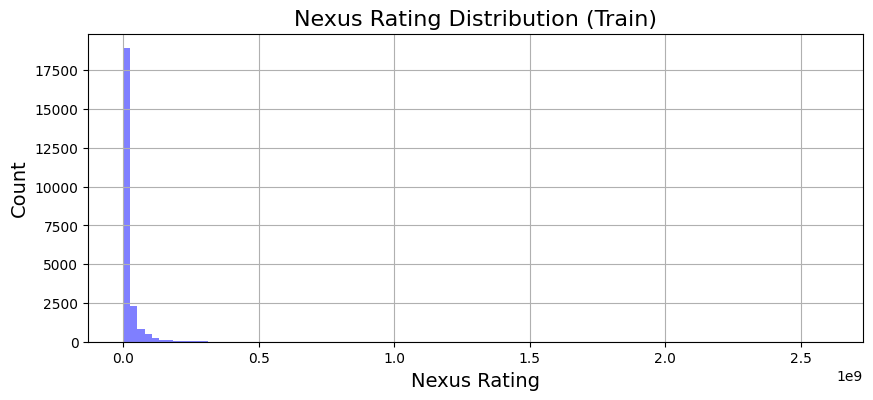

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
train['nexus_rating'].hist(bins=100, ax=ax, color='blue', alpha=0.5, label='Train Target Distributuon')
ax.set_title('Nexus Rating Distribution (Train)', fontsize=16)
ax.set_xlabel('Nexus Rating', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

In [47]:
from sklearn.metrics import mean_squared_log_error

def rmsle(y_true, y_pred):
    """ Root Mean Squared Logarithmic Error """
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

In [48]:
# Example rmsle check
test['pred'] = 0
print('RMSLE: ', rmsle(test['nexus_rating'], test['pred']))
print('Required RMSLE: ', 0.294)

RMSLE:  4.203250078450383
Required RMSLE:  0.294


In [49]:

test_raw = test.copy()
test['energy_footprint'] = test_raw['nexus_rating']    
test['nexus_rating']     = test_raw['grid_connections'] 
test['grid_connections']     = test_raw['efficiency_grade'] 
test['core_reactor_size']     = test_raw['energy_footprint'] 
test['vertical_alignment']     = test_raw['harvesting_space'] 
test['harvesting_space']     = test_raw['core_reactor_size'] 
test['energy_flow_design']     = test_raw['power_chambers'] 
test['upper_collector_height']     = test_raw['energy_flow_design'] 
test['efficiency_grade']     = test_raw['shielded_harvesters'] 
test['power_chambers']     = test_raw['vertical_alignment'] 
#test['isolated_conversion_units']     = test_raw['upper_collector_height'] 

test['shielded_harvesters']     = test_raw['external_collectors'] 

#test['external_collectors']     = test_raw['isolated_conversion_units'] 
test['shared_conversion_units'] = test_raw['upper_collector_height']

test['isolated_conversion_units'] = test_raw['shared_conversion_units']
test['internal_collectors']     = test_raw['isolated_conversion_units']
test['external_collectors']     = test_raw['internal_collectors']




# Features 
TARGET = "nexus_rating"
features = [c for c in train.columns if c != TARGET]

X = train[features].copy()
y = np.log1p(train[TARGET].values)   
X_test = test[features].copy()
y_test = np.log1p(test[TARGET].values)  

X = X.fillna(-1)
X_test = X_test.fillna(-1)

# Encode categoricals
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].astype(str)
        X_test[col] = X_test[col].astype(str)
        le = LabelEncoder()
        le.fit(pd.concat([X[col], X_test[col]]))
        X[col] = le.transform(X[col])
        X_test[col] = le.transform(X_test[col])



In [52]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
models = {
    "lightgbm": lgb.LGBMRegressor(
        objective="regression",
        learning_rate=0.005,
        num_leaves=256,
        n_estimators=2500,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ),
    "xgboost": xgb.XGBRegressor(
        objective="reg:squarederror",
        learning_rate=0.005,
        max_depth=14,
        n_estimators=2500,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        tree_method="hist"
    ),
    "catboost": CatBoostRegressor(
        objective="RMSE",
        learning_rate=0.01,
        depth=10,
        iterations=2000,
        random_seed=42,
        verbose=0
    ),
    "extratrees": ExtraTreesRegressor(
        n_estimators=1000,
        max_depth=None,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    )
}

In [53]:

# Train the models
preds = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X, y)
    preds.append(model.predict(X_test))

preds = np.column_stack(preds)


# Automatic Blending 
meta = LinearRegression(positive=True)
meta.fit(preds, y_test) 
y_pred_log = meta.predict(preds)
y_pred = np.expm1(y_pred_log)


score = rmsle(np.expm1(y_test), y_pred)
print(f"Final Ensemble RMSLE: {score:.6f}")
print("Blending Weights:", meta.coef_ / meta.coef_.sum())

Training lightgbm...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 972
[LightGBM] [Info] Number of data points in the train set: 23285, number of used features: 16
[LightGBM] [Info] Start training from score 16.430482
Training xgboost...
Training catboost...
Training extratrees...
Final Ensemble RMSLE: 0.292866
Blending Weights: [0.3232953  0.06636478 0.43006046 0.18027946]


# 2a. Explain your threshold-breaking strategy
Firstly I manually compared the train and test dataset to fix the tampered coloumns. Tried to do it automatically but got worse results. Secondly I applied log1p for more stable curve since RMSLE is log based. Thridly I filled in missing values with -1 and used labe encoder to ensure mapping between the train and test was consistent. I also used multiple models in an ensamble and used automatic blending weights to get the best score as possible. 

# 2b. Justify RMSLE usage. Why do we use this metric? Which loss function did you use?
We used RMSLE because, it penalizes relative errors rather than absolute errors. In addition over predictions and under predictions are penalized more symmetrically on a log scale. Lastly large outliers in energy consumption do not dominate the error metric as they would in RMSE.

I used log1p as the loss function since it fits well for RMSLE

# 2c Plot and interpret feature importances


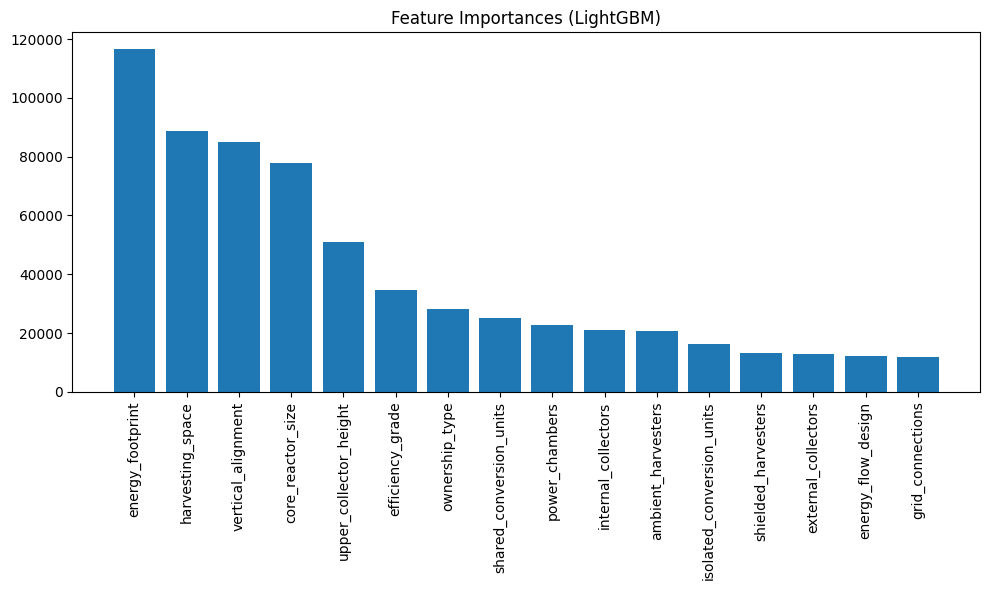

In [54]:
lgb_model = models["lightgbm"]
importances = lgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances (LightGBM)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

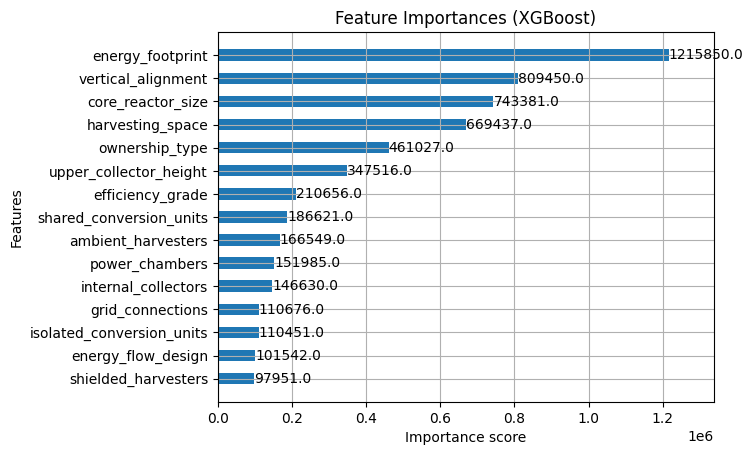

In [55]:
xgb.plot_importance(models["xgboost"], importance_type="weight", max_num_features=15, height=0.5)
plt.title("Feature Importances (XGBoost)")
plt.show()

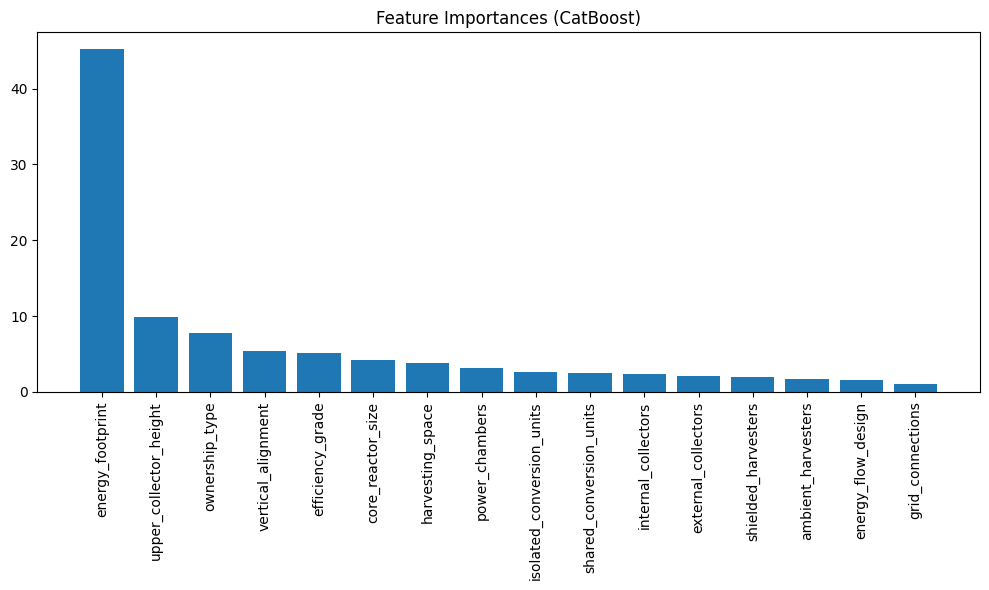

In [56]:
cat_model = models["catboost"]
cat_importances = cat_model.get_feature_importance()
sorted_idx = np.argsort(cat_importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances (CatBoost)")
plt.bar(range(len(cat_importances)), cat_importances[sorted_idx])
plt.xticks(range(len(cat_importances)), [features[i] for i in sorted_idx], rotation=90)
plt.tight_layout()
plt.show()

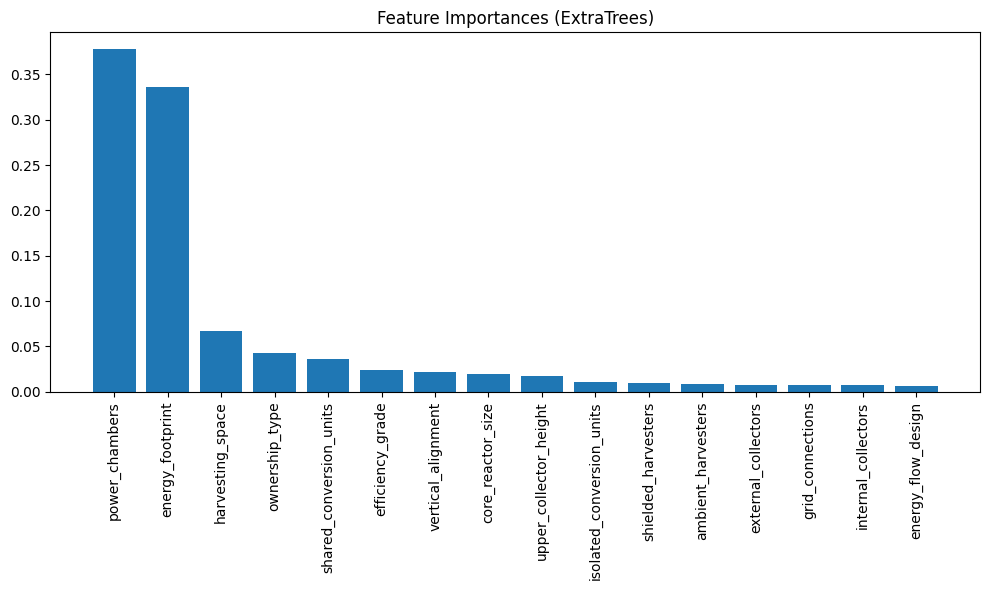

In [57]:
et_model = models["extratrees"]
et_importances = et_model.feature_importances_
et_indices = np.argsort(et_importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances (ExtraTrees)")
plt.bar(range(len(et_importances)), et_importances[et_indices], align="center")
plt.xticks(range(len(et_importances)), [features[i] for i in et_indices], rotation=90)
plt.tight_layout()
plt.show()


In all of the plots Energy_footprint was one of the most predictive features for each model. It must have been connected to the nexus rating somehow so when "skynet" stole power it left a bigger energy_footprint and was because of that one of the biggest helpers for the models. On the Lightgbm and Xgboost both other top contributers is the vertical alignment, harvesting_space and core_reactor size. They may have some connection to nexsus rating but I have no clue what since its column names are a bit absract for me ahah.

Every model least important was pretty diffrent but two of them had grid_connections as last so it was less important data to find the pattern.

# 2d. Describe your ensembling techniques
I used weighted ensamble of three diffrent gradient boosting models plus a trees models. Each of them captures a diffrent aspect of the feature space and makes the loss less. After that i used automatics weights to blend them togheter to get optimal blending.

# 2e. In real life, you do not have the test targets. How would you make sure your model will work good on the unseen data?
Maybe i could use cross validation like k-fold on the csv data on the training set to simulate the unseen data. I could also compare features betwen train and test data to detect shift in data and correct it.

In [58]:
def match_test_to_train(train_df, test_df):
    mapping = {}
    for test_col in test_df.columns:
        best_score = np.inf
        best_train_col = None
        test_values = test_df[test_col].fillna(0).values
        for train_col in train_df.columns:
            train_values = train_df[train_col].fillna(0).values

            score = (np.mean(test_values) - np.mean(train_values))**2 + \
                    (np.std(test_values) - np.std(train_values))**2
            if score < best_score:
                best_score = score
                best_train_col = train_col
        mapping[test_col] = best_train_col
    return mapping


column_mapping = match_test_to_train(train, test)
print(" Suggested test -> train column mapping:")
for test_col, train_col in column_mapping.items():
    print(f"{test_col} -> {train_col}")


 Suggested test -> train column mapping:
ownership_type -> ownership_type
nexus_rating -> nexus_rating
energy_footprint -> energy_footprint
core_reactor_size -> core_reactor_size
harvesting_space -> harvesting_space
vertical_alignment -> vertical_alignment
power_chambers -> power_chambers
energy_flow_design -> energy_flow_design
upper_collector_height -> upper_collector_height
shared_conversion_units -> shared_conversion_units
isolated_conversion_units -> isolated_conversion_units
internal_collectors -> internal_collectors
external_collectors -> external_collectors
ambient_harvesters -> ambient_harvesters
shielded_harvesters -> ambient_harvesters
efficiency_grade -> efficiency_grade
grid_connections -> grid_connections
pred -> energy_flow_design
